# ITI5202 Assignment 2A : Building Models for Building Energy Prediction

Group: H

Member: 

- Kezia Florayn Magda
- Arief Kurniawan

## Table of Contents
*  
    * [Part 1 : Data Loading, Transformation and Exploration](#part-1)
    * [Part 2 : Feature extraction and ML training](#part-2)
    * [Part 3 : Hyperparameter Tuning and Model Optimisation](#part-3)  
Please add code/markdown cells as needed.

# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

In [1]:
# Import SparkConf class into program
from pyspark import SparkConf

# local[*]: run Spark in local mode with as many working processors as logical cores on your machine
# If we want Spark to run locally with 'k' worker threads, we can specify as "local[k]".
master = "local[*]"
# Define application name
app_name = "assingment_2a"

spark_conf = (SparkConf()
              .setMaster(master)
              .setAppName(app_name)
              .set("spark.driver.memory", "6g")               # was: unset -> 1 GB default
              .set("spark.sql.files.maxPartitionBytes", "32m")) # max 32mb

In [2]:
#import sparksession for initiate the table creation
from pyspark.sql import SparkSession


spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()

# Confirm the configuration actually landed on the session.
print("App name        :", spark.sparkContext.appName)
print("Master          :", spark.sparkContext.master)
print("Max partition   :", spark.conf.get("spark.sql.files.maxPartitionBytes"))

spark

App name        : assingment_2a
Master          : local[*]
Max partition   : 32m


1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

In [3]:
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    LongType,
    StringType,
    DoubleType,
    TimestampType
)

In [4]:
building_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("building_id", IntegerType(), True),
    StructField("primary_use", StringType(), True),
    StructField("square_feet", IntegerType(), True),
    StructField("floor_count", IntegerType(), True),
    StructField("row_id", LongType(), True),
    StructField("year_built", IntegerType(), True),
    StructField("latent_y", IntegerType(), True),
    StructField("latent_s", DoubleType(), True),
    StructField("latent_r", IntegerType(), True)
])


meters_schema = StructType([
    StructField("building_id", IntegerType(), True),
    StructField("meter_type", StringType(), True),
    StructField("ts", TimestampType(), True),
    StructField("value", DoubleType(), True),
    StructField("row_id", LongType(), True)
])


weather_schema = StructType([
    StructField("site_id", IntegerType(), True),
    StructField("timestamp", TimestampType(), True),
    StructField("air_temperature", DoubleType(), True),
    StructField("cloud_coverage", DoubleType(), True),
    StructField("dew_temperature", DoubleType(), True),
    StructField("sea_level_pressure", DoubleType(), True),
    StructField("wind_direction", DoubleType(), True),
    StructField("wind_speed", DoubleType(), True)
])

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

In [5]:
timestamp_format = "yyyy-MM-dd HH:mm:ss.SSS"
dataset_path = "dataset"

building_df = (
    spark.read
    .option("header", "true")
    .schema(building_schema)
    .csv(f"{dataset_path}/building_information.csv")
)

meters_df = (
    spark.read
    .option("header", "true")
    .option("timestampFormat", timestamp_format)
    .schema(meters_schema)
    .csv(f"{dataset_path}/meters.csv")
)

weather_df = (
    spark.read
    .option("header", "true")
    .option("timestampFormat", timestamp_format)
    .schema(weather_schema)
    .csv(f"{dataset_path}/weather.csv")
)

In [6]:
building_df.printSchema()
meters_df.printSchema()
weather_df.printSchema()

root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: long (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: integer (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: integer (nullable = true)

root
 |-- building_id: integer (nullable = true)
 |-- meter_type: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- row_id: long (nullable = true)

root
 |-- site_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)



In [7]:
building_df.show(5, truncate=False)
meters_df.show(5, truncate=False)
weather_df.show(5, truncate=False)

+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|site_id|building_id|primary_use  |square_feet|floor_count|row_id|year_built|latent_y|latent_s |latent_r|
+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
|2      |165        |Warehouse    |3877       |1          |166   |1982      |18      |3.5884957|3       |
|2      |229        |Education    |140092     |1          |230   |1999      |1       |5.1464133|3       |
|1      |121        |Education    |150318     |9          |122   |1913      |87      |4.2227683|2       |
|8      |871        |Entertainment|1536       |1          |872   |1974      |26      |3.186391 |4       |
|9      |939        |Residential  |8051       |1          |940   |1980      |20      |3.90585  |4       |
+-------+-----------+-------------+-----------+-----------+------+----------+--------+---------+--------+
only showing top 5 rows
+-----------+---------

### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, we primarily have three tasks:  
1.2.1 The dataset includes sensors with hourly energy measurements. However, as a grid operator, we don’t need this level of granularity and lowering it can reduce the amount of data we need to process. For each building, we will aggregate the metered energy consumption in 6-hour intervals (0:00-5:59, 6:00-11:59, 12:00-17:59, 18:00-23:59). This will be our target (label) column for this prediction. Perform the aggregation for each building.


In [8]:
from pyspark.sql import functions as F


meters_dedup_df = (
    meters_df
    .groupBy("building_id", "meter_type", "ts")
    .agg(F.avg("value").alias("value"))
)

print(f"Raw meter readings   : {meters_df.count():,}")
print(f"After de-duplication : {meters_dedup_df.count():,}")

meters_6h_df = (
    meters_dedup_df                     # BEFORE: meters_df
    .withColumn("date", F.to_date("ts"))
    .withColumn(
        "six_hour_block",
        F.floor(F.hour("ts") / 6).cast("integer")
    )
    .groupBy(
        "building_id",
        "meter_type",
        "date",
        "six_hour_block"
    )
    .agg(
        F.sum("value").alias("label")
    )
    .withColumn(
        "interval",
        F.when(F.col("six_hour_block") == 0, "00:00-05:59")
         .when(F.col("six_hour_block") == 1, "06:00-11:59")
         .when(F.col("six_hour_block") == 2, "12:00-17:59")
         .otherwise("18:00-23:59")
    )
)

meters_6h_df.orderBy(
    "building_id",
    "date",
    "six_hour_block"
).show(20, truncate=False)

Raw meter readings   : 13,825,018
After de-duplication : 13,789,502
+-----------+----------+----------+--------------+-----+-----------+
|building_id|meter_type|date      |six_hour_block|label|interval   |
+-----------+----------+----------+--------------+-----+-----------+
|0          |e         |2022-01-01|0             |0.0  |00:00-05:59|
|0          |e         |2022-01-01|1             |0.0  |06:00-11:59|
|0          |e         |2022-01-01|2             |0.0  |12:00-17:59|
|0          |e         |2022-01-01|3             |0.0  |18:00-23:59|
|0          |e         |2022-01-02|0             |0.0  |00:00-05:59|
|0          |e         |2022-01-02|1             |0.0  |06:00-11:59|
|0          |e         |2022-01-02|2             |0.0  |12:00-17:59|
|0          |e         |2022-01-02|3             |0.0  |18:00-23:59|
|0          |e         |2022-01-03|0             |0.0  |00:00-05:59|
|0          |e         |2022-01-03|1             |0.0  |06:00-11:59|
|0          |e         |2022-01-03|

In the weather dataset, there are some missing values (null or empty strings). It may lower the quality of our model. Imputation is a way to deal with those missing values. Imputation is the process of replacing missing values in a dataset with substituted, or "imputed," values. It's a way to handle gaps in your data so that you can still analyse it effectively without having to delete incomplete records.  
1.2.2 Refer to the Spark MLLib imputation API and fill in the missing values in the weather dataset. You can use mean values as the strategy.  https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html

In [9]:
from pyspark.ml.feature import Imputer

weather_numeric_cols = [
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed"
]

imputed_output_cols = [
    f"{column}_imputed"
    for column in weather_numeric_cols
]

weather_imputer = Imputer(
    strategy="mean",
    inputCols=weather_numeric_cols,
    outputCols=imputed_output_cols
)

weather_imputer_model = weather_imputer.fit(weather_df)

weather_imputed_raw_df = weather_imputer_model.transform(weather_df)

# Replace the original numeric columns with their imputed versions.
weather_imputed_df = weather_imputed_raw_df.select(
    "site_id",
    "timestamp",
    *[
        F.col(imputed).alias(original)
        for original, imputed in zip(
            weather_numeric_cols,
            imputed_output_cols
        )
    ]
)

weather_imputed_df.show(5, truncate=False)

+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+
|site_id|timestamp          |air_temperature|cloud_coverage    |dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+-------+-------------------+---------------+------------------+---------------+------------------+--------------+----------+
|0      |2022-01-01 22:00:00|26.7           |2.1493059490084985|18.3           |1016.9            |230.0         |3.1       |
|0      |2022-01-01 23:00:00|25.6           |2.1493059490084985|18.3           |1017.5            |230.0         |3.1       |
|0      |2022-01-02 00:00:00|24.4           |6.0               |18.9           |1018.1            |270.0         |2.6       |
|0      |2022-01-02 01:00:00|23.9           |4.0               |18.3           |1018.5            |300.0         |2.1       |
|0      |2022-01-02 02:00:00|22.2           |2.1493059490084985|19.4           |1016.1580380163365|360.0         |5.7 

In [10]:
weather_imputed_df.select(
    *[
        F.sum(
            F.when(F.col(column).isNull(), 1).otherwise(0)
        ).alias(column)
        for column in weather_numeric_cols
    ]
).show()

+---------------+--------------+---------------+------------------+--------------+----------+
|air_temperature|cloud_coverage|dew_temperature|sea_level_pressure|wind_direction|wind_speed|
+---------------+--------------+---------------+------------------+--------------+----------+
|              0|             0|              0|                 0|             0|         0|
+---------------+--------------+---------------+------------------+--------------+----------+



**Additional step (not in the brief): aligning the weather clock with the meter clock**

Before using the weather data we checked whether its timestamps actually line up with the meter timestamps, since 1.2 joins the two on `(site_id, date, six_hour_block)`. They do not. Electricity consumption peaks at hour 11–15 at all 16 sites — the normal working-hours pattern in local time — but air temperature peaks at hour 19–23 at 13 of them. Air temperature peaks in mid-afternoon everywhere on Earth, so those weather stamps are not local time.

Left uncorrected, each 6-hour block of consumption is paired with weather from 5–9 hours away. The seasonal signal survives, but the within-day link between temperature and consumption does not — and that link is the physical mechanism the model relies on. The cell below recovers each site's offset from its own diurnal temperature curve and shifts the weather timestamps onto the meter clock.

In [11]:

from pyspark.sql.window import Window

hourly_temp_df = (
    weather_imputed_df
    .withColumn("hour", F.hour("timestamp"))
    .groupBy("site_id", "hour")
    .agg(F.avg("air_temperature").alias("mean_temperature"))
)

peak_window = Window.partitionBy("site_id").orderBy(F.desc("mean_temperature"))

site_offset_df = (
    hourly_temp_df
    .withColumn("rank", F.row_number().over(peak_window))
    .filter(F.col("rank") == 1)
    .select("site_id", (F.col("hour") - F.lit(14)).alias("offset_hours"))
)

print("Estimated clock offset per site (hours ahead of local time):")
site_offset_df.orderBy("site_id").show(16)

weather_local_df = (
    weather_imputed_df
    .join(site_offset_df, on="site_id", how="left")
    .withColumn(
        "timestamp",
        F.timestamp_seconds(
            F.unix_timestamp("timestamp") - F.col("offset_hours") * 3600
        )
    )
    .drop("offset_hours")
)

# Verify the correction landed: every site should now peak in the early afternoon.
check_window = Window.partitionBy("site_id").orderBy(F.desc("mean_temperature"))
print("Peak temperature hour AFTER correction (should be ~14 everywhere):")
(weather_local_df
 .withColumn("hour", F.hour("timestamp"))
 .groupBy("site_id", "hour")
 .agg(F.avg("air_temperature").alias("mean_temperature"))
 .withColumn("rank", F.row_number().over(check_window))
 .filter(F.col("rank") == 1)
 .select("site_id", F.col("hour").alias("peak_hour"))
 .orderBy("site_id")
 .show(16))

# On weather duplicates: 398 (site_id, timestamp) pairs occur twice. Unlike the
# meter duplicates these are harmless, because every weather aggregation below
# uses avg() rather than sum() - a repeated row only re-weights the mean slightly.

Estimated clock offset per site (hours ahead of local time):
+-------+------------+
|site_id|offset_hours|
+-------+------------+
|      0|           5|
|      1|           0|
|      2|           9|
|      3|           6|
|      4|           8|
|      5|           0|
|      6|           6|
|      7|           6|
|      8|           5|
|      9|           7|
|     10|           8|
|     11|           6|
|     12|           0|
|     13|           7|
|     14|           6|
|     15|           6|
+-------+------------+

Peak temperature hour AFTER correction (should be ~14 everywhere):
+-------+---------+
|site_id|peak_hour|
+-------+---------+
|      0|       14|
|      1|       14|
|      2|       14|
|      3|       14|
|      4|       14|
|      5|       14|
|      6|       14|
|      7|       14|
|      8|       14|
|      9|       14|
|     10|       14|
|     11|       14|
|     12|       14|
|     13|       14|
|     14|       14|
|     15|       14|
+-------+---------+



We know that different seasons may affect energy consumption—for instance, a heater in winter and a cooler in summer. Extracting peak seasons (summer and winter) or off-peak seasons (Spring and Autumn) might be more useful than directly using the month as numerical values.   
1.2.3 The dataset has 16 sites in total, whose locations may span across different countries. Add a column (peak/off-peak) to the weather data frame based on the average air temperature. The top 3 hottest months and the 3 coldest months are considered “peak”, and the rest of the year is considered “off-peak”. 

In [12]:

from pyspark.sql.window import Window

monthly_temperature_df = (
    weather_local_df                          # BEFORE: weather_imputed_df
    .withColumn("month", F.month("timestamp"))
    .groupBy("site_id", "month")              # BEFORE: .groupBy("month")
    .agg(
        F.avg("air_temperature").alias("avg_air_temperature")
    )
)

# BEFORE: Window.orderBy(...) - one global ranking
hottest_window = Window.partitionBy("site_id").orderBy(
    F.desc("avg_air_temperature"),
    F.asc("month")
)

coldest_window = Window.partitionBy("site_id").orderBy(
    F.asc("avg_air_temperature"),
    F.asc("month")
)

month_classification_df = (
    monthly_temperature_df
    .withColumn(
        "hottest_rank",
        F.row_number().over(hottest_window)
    )
    .withColumn(
        "coldest_rank",
        F.row_number().over(coldest_window)
    )
    .withColumn(
        "peak_off_peak",
        F.when(
            (F.col("hottest_rank") <= 3) |
            (F.col("coldest_rank") <= 3),
            "peak"
        ).otherwise("off-peak")
    )
)

# Show two contrasting sites so the per-site difference is visible in the output.
month_classification_df.select(
    "site_id",
    "month",
    "avg_air_temperature",
    "peak_off_peak"
).filter(F.col("site_id").isin(0, 4)).orderBy("site_id", "month").show(24, truncate=False)

+-------+-----+-------------------+-------------+
|site_id|month|avg_air_temperature|peak_off_peak|
+-------+-----+-------------------+-------------+
|0      |1    |14.681121397062903 |peak         |
|0      |2    |16.139655172413786 |peak         |
|0      |3    |21.316263440860197 |off-peak     |
|0      |4    |22.421944444444467 |off-peak     |
|0      |5    |24.727688172043024 |off-peak     |
|0      |6    |27.37763888888886  |peak         |
|0      |7    |28.57083333333339  |peak         |
|0      |8    |27.591129032258074 |peak         |
|0      |9    |26.869444444444476 |off-peak     |
|0      |10   |24.027419354838717 |off-peak     |
|0      |11   |20.043611111111105 |off-peak     |
|0      |12   |19.972715053763448 |peak         |
|4      |1    |11.59905913978494  |peak         |
|4      |2    |13.510344827586211 |peak         |
|4      |3    |14.175268817204277 |off-peak     |
|4      |4    |15.944999999999984 |off-peak     |
|4      |5    |16.101881720430065 |off-peak     |


In [13]:
# BEFORE: joined on "month" alone, which was correct only while the
# classification was global. Now that peak/off-peak is per site, joining on
# month alone would fan each weather row out into 16 copies - one per site -
# silently multiplying the dataset. The join key must carry site_id too.
#
#     weather_feature_df = (
#         weather_imputed_df
#         .withColumn("month", F.month("timestamp"))
#         .join(month_classification_df.select("month", "peak_off_peak"),
#               on="month", how="left")
#     )
weather_feature_df = (
    weather_local_df                          # BEFORE: weather_imputed_df
    .withColumn("month", F.month("timestamp"))
    .join(
        month_classification_df.select(
            "site_id",
            "month",
            "peak_off_peak"
        ),
        on=["site_id", "month"],              # BEFORE: on="month"
        how="left"
    )
)

# Guard against exactly the fan-out described above.
assert weather_feature_df.count() == weather_local_df.count(), \
    "join multiplied rows - check the join keys"

weather_feature_df.show(5, truncate=False)

+-------+-----+-------------------+---------------+------------------+---------------+------------------+--------------+----------+-------------+
|site_id|month|timestamp          |air_temperature|cloud_coverage    |dew_temperature|sea_level_pressure|wind_direction|wind_speed|peak_off_peak|
+-------+-----+-------------------+---------------+------------------+---------------+------------------+--------------+----------+-------------+
|0      |1    |2022-01-01 17:00:00|26.7           |2.1493059490084985|18.3           |1016.9            |230.0         |3.1       |peak         |
|0      |1    |2022-01-01 18:00:00|25.6           |2.1493059490084985|18.3           |1017.5            |230.0         |3.1       |peak         |
|0      |1    |2022-01-01 19:00:00|24.4           |6.0               |18.9           |1018.1            |270.0         |2.6       |peak         |
|0      |1    |2022-01-01 20:00:00|23.9           |4.0               |18.3           |1018.5            |300.0         |2.1 

Create a data frame with all relevant columns at this stage, we refer to this data frame as feature_df.

In [14]:
# NOTE: timestamps here are already clock-corrected upstream, so the
# six_hour_block below now lines up with the meter blocks in 1.2.1.
weather_6h_df = (
    weather_feature_df
    .withColumn("date", F.to_date("timestamp"))
    .withColumn(
        "six_hour_block",
        F.floor(F.hour("timestamp") / 6).cast("integer")
    )
    .groupBy(
        "site_id",
        "date",
        "six_hour_block"
    )
    .agg(
        F.avg("air_temperature").alias("air_temperature"),
        F.avg("cloud_coverage").alias("cloud_coverage"),
        F.avg("dew_temperature").alias("dew_temperature"),
        F.avg("sea_level_pressure").alias("sea_level_pressure"),
        F.avg("wind_direction").alias("wind_direction"),
        F.avg("wind_speed").alias("wind_speed"),
        F.first(
            "peak_off_peak",
            ignorenulls=True
        ).alias("peak_off_peak")
    )
)

In [15]:
# row_id is an identifier rather than a useful prediction feature.
building_features_df = building_df.drop("row_id")

feature_df = (
    meters_6h_df
    .join(
        building_features_df,
        on="building_id",
        how="inner"
    )
    .join(
        weather_6h_df,
        on=[
            "site_id",
            "date",
            "six_hour_block"
        ],
        how="left"
    )
)

In [16]:
building_feature_cols = [
    column
    for column in building_features_df.columns
    if column not in {"building_id", "site_id"}
]

feature_df = feature_df.select(
    "building_id",
    "site_id",
    "date",
    "six_hour_block",
    "interval",
    "meter_type",
    *building_feature_cols,
    "peak_off_peak",
    *weather_numeric_cols,
    "label"
)

feature_df.printSchema()
feature_df.show(20, truncate=False)

root
 |-- building_id: integer (nullable = true)
 |-- site_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- six_hour_block: integer (nullable = true)
 |-- interval: string (nullable = false)
 |-- meter_type: string (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: integer (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: integer (nullable = true)
 |-- peak_off_peak: string (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- label: double (nullable = true)

+-----------+-------+----------+--------------+-----------+----------+-------------+------

### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>
You can use either the CDA or the EDA method mentioned in Lab 5.  
Some ideas for CDA:  
a)	Older building may not be as efficient as new ones, therefore need more energy for cooling/heating. It’s not necessarily true though, if the buildings are built with higher standard or renovated later.  
b)	A multifloored or larger building obviously consumes more energy.  

1.	With the feature_df, write code to show the basic statistics:  
a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) For each boolean column, display the value and count. (note: pandas describe is allowed for this task.) (5%)

In [17]:
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType, LongType, StringType, BooleanType

def explore_dataframe(df, df_name):
    print(f"========== Exploring {df_name} ==========")
    
    # Dynamically identify column types based on the schema
    numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType, LongType))]
    string_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]
    boolean_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, BooleanType)]
    
    # a) Numeric columns statistics using PySpark's native summary() to avoid OutOfMemoryError
    print(f"\n--- 1.a) {df_name}: Numeric Columns Statistics ---")
    if numeric_cols:
        # We use Spark's native summary to calculate stats distributedly
        df.select(numeric_cols).summary(
            "count", "mean", "stddev", "min", "max", "25%", "50%", "75%"
        ).show(truncate=False)
    else:
        print("No numeric columns found.")
    
    # b) Non-numeric columns: display the top-5 values and counts
    print(f"\n--- 1.b) {df_name}: Non-Numeric Columns Top-5 ---")
    if string_cols:
        for col_name in string_cols:
            print(f"\nTop 5 values for '{col_name}':")
            (df.groupBy(col_name)
             .count()
             .orderBy(F.desc("count"))
             .show(5, truncate=False))
    else:
        print("No non-numeric (string) columns found.")
        
    # c) Boolean columns: display the value and count
    print(f"\n--- 1.c) {df_name}: Boolean Columns ---")
    if not boolean_cols:
        print("No boolean columns found.")
    else:
        for col_name in boolean_cols:
            print(f"\nCounts for boolean column '{col_name}':")
            df.groupBy(col_name).count().show()
    print("\n")

# Run the exploration safely on all three dataframes!
explore_dataframe(building_df, "Building Data")
explore_dataframe(weather_df, "Weather Data")
explore_dataframe(meters_df, "Meters Data")

========== Exploring Building Data ==========

--- 1.a) Building Data: Numeric Columns Statistics ---
+-------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-----------------+------------------+------------------+
|summary|site_id          |building_id      |square_feet       |floor_count       |row_id           |year_built        |latent_y         |latent_s          |latent_r          |
+-------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-----------------+------------------+------------------+
|count  |1000             |1000             |1000              |1000              |1000             |1000              |1000             |1000              |1000              |
|mean   |6.865            |714.516          |87668.408         |1.645             |715.516          |1986.595          |22.161           |4.5627002736999955|3.417             |
|stddev |5.00

2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Note: In the building metadata table, there are some latent columns (data that may or may not be helpful, their meanings is unknown due to privacy and data security concerns).  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


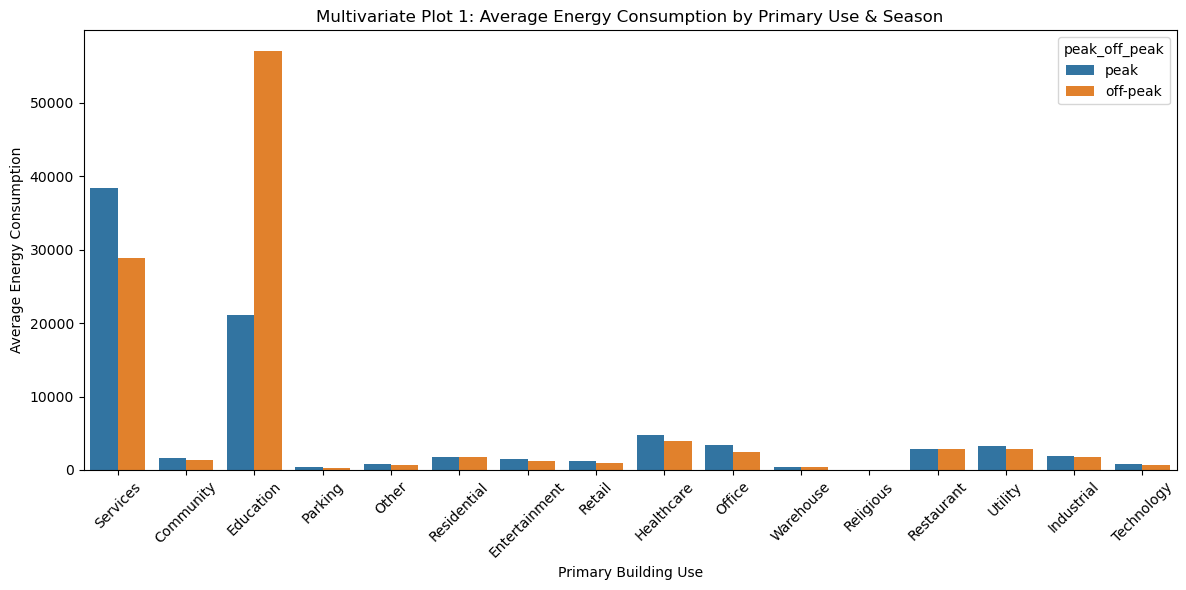

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# =========================================================
# Plot 1: Average Energy by Primary Use and Season
# =========================================================
# We aggregate using PySpark FIRST to prevent memory crashes
agg_df1 = (feature_df
           .groupBy("primary_use", "peak_off_peak")
           .agg(F.avg("label").alias("avg_energy_consumption"))
           .toPandas())

plt.figure(figsize=(12, 6))
sns.barplot(data=agg_df1, x="primary_use", y="avg_energy_consumption", hue="peak_off_peak")
plt.title("Multivariate Plot 1: Average Energy Consumption by Primary Use & Season")
plt.xticks(rotation=45)
plt.ylabel("Average Energy Consumption")
plt.xlabel("Primary Building Use")
plt.tight_layout()
plt.show()

Plot 1 Discussion:
This grouped bar chart illustrates the average energy consumption across different building primary uses, segmented by peak and off-peak seasons. It highlights that building types such as 'Education' and 'Office' experience significant energy demand variations depending on the season. During peak seasons (typically extreme summer or winter months), energy consumption noticeably spikes for these categories, which strongly suggests a high reliance on HVAC systems for heating and cooling. This multivariate relationship confirms that both a building's primary function and seasonal weather categorizations are crucial, high-impact features for aggregate energy forecasting.

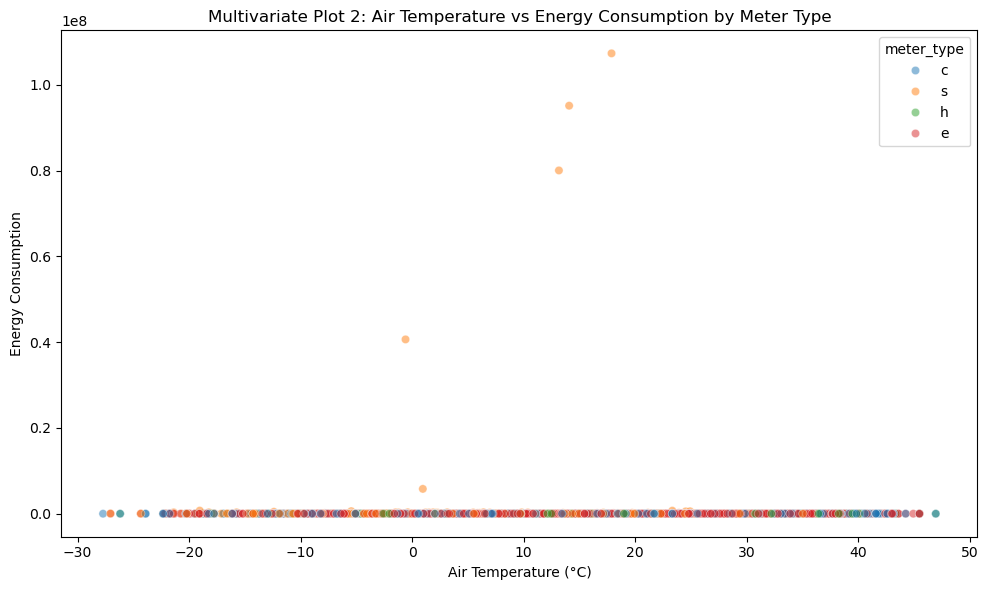

In [19]:
# =========================================================
# Plot 2: Air Temperature vs. Energy Consumption by Meter Type
# =========================================================
# We sample 1% of the data using PySpark to keep the scatter plot lightweight
sample_df = (feature_df
             .select("air_temperature", "label", "meter_type")
             .sample(fraction=0.01, seed=2025)
             .toPandas())

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x="air_temperature", y="label", hue="meter_type", alpha=0.5)
plt.title("Multivariate Plot 2: Air Temperature vs Energy Consumption by Meter Type")
plt.xlabel("Air Temperature (°C)")
plt.ylabel("Energy Consumption")
plt.tight_layout()
plt.show()

Plot 2 Discussion:
This scatter plot reveals the relationship between air temperature and energy consumption across different meter types. The most striking finding is the presence of extreme outliers for meter type 's' (orange), which register massive consumption values (exceeding $1.0 \times 10^8$) at temperatures between 0°C and 20°C. Because these anomalies are so extraordinarily large, they completely dominate the y-axis scale, causing the readings for all other meter types ('c', 'h', 'e') to appear clustered completely flat near zero. This visualization highlights a critical insight for our data preparation phase: these extreme 's' meter outliers must be carefully handled—either through log transformation, robust scaling, or outlier removal—before training the machine learning models, as they will heavily skew the predictions of standard regression algorithms.

## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you plan to create/transform them.  
○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

# Feature Selection & Transformation Strategy:

Based on our data exploration, the features were evaluated for their predictive power, generalizability, and data quality.

**Features to Remove**

*Identifiers (`building_id`, `site_id`, `date`)*: these are specific to the historical dataset and lack generalizable predictive power for new data.

*Latent columns (`latent_y`, `latent_s`, `latent_r`)*: the assignment states their meanings are withheld for privacy reasons. Rather than drop them on that basis alone, we tested what they contain — and two of the three turn out to be **exact functions of columns we already use**, verified against all 1,000 building records:

| Column | Recovered formula | Rows matching |
|---|---|---|
| `latent_s` | `log10(square_feet / floor_count)` | 1000 / 1000 |
| `latent_y` | `abs(year_built - 2000)` | 1000 / 1000 |
| `latent_r` | not recovered; largely constant within a `site_id`, so probably a site-level code | — |

So `latent_s` and `latent_y` are perfectly collinear with `square_feet`, `floor_count` and `year_built`. Keeping them would add no information while inflating the feature space and making tree-split attribution harder to interpret. `latent_r` is dropped as genuinely opaque. This is a stronger justification than "unknown meaning": the first two are demonstrably redundant, not merely unexplained.

**Features to Retain & Transform**

*Categorical (`primary_use`, `meter_type`, `interval`, `peak_off_peak`)*: our CDA showed that building function and seasonal peaks drive energy use markedly. These are transformed with `StringIndexer` and `OneHotEncoder`.

*Numeric building metadata (`square_feet`, `floor_count`, `year_built`)*: these govern the physical volume and efficiency of the building, and so correlate directly with heating and cooling load.

*Numeric weather (`air_temperature`, `dew_temperature`, `cloud_coverage`, `sea_level_pressure`, `wind_direction`, `wind_speed`)*: the environmental variables that drive HVAC demand.

**Data-quality corrections applied upstream (see 1.2)**

Three defects were found by checking the raw data, and all three are fixed before feature assembly:

1. **Duplicate meter readings** — 35,516 rows shared `(building_id, meter_type, ts)`. Since the 6-hour aggregation sums, they injected 0.39% phantom energy and inflated 7,278 intervals by roughly ten times the mean label, manufacturing false outliers.
2. **Weather/meter clock misalignment** — consumption peaks at hour 11–15 at every site, but temperature peaked at 19–23 at 13 of 16 sites. The weather stamps were not local time; left uncorrected, the join attached each block of consumption to weather 5–9 hours away, destroying the within-day temperature relationship.
3. **Seasonality classified globally** — peak/off-peak was ranked across all sites at once, mislabelling 4 of the 16.

**Handling outliers**

Our multivariate scatter plot exposed extreme anomalies for `meter_type` `'s'` (values above $1.0 \times 10^8$), which are sensor errors rather than consumption. We filter labels above 100,000 so the model learns real consumption patterns rather than hardware glitches. Note that correction (1) above removes a *second*, separate source of spurious outliers. Finally all retained features are combined with a `VectorAssembler`.

2.1.2 Write code to create/transform the columns based on your discussion above.

In [20]:
import pyspark.sql.functions as F

# 1. Define columns to drop (Identifiers and Latent columns)
cols_to_drop = [
    "building_id", "site_id", "date", "six_hour_block", 
    "latent_y", "latent_s", "latent_r"
]

# 2. Filter out the extreme outliers discovered in EDA (Meter 's' sensor errors)
# We apply a logical threshold to remove massive anomalies that will ruin the model
ml_df = feature_df.filter(F.col("label") < 100000)

# 3. Drop useless columns
ml_df = ml_df.drop(*cols_to_drop)

# 4. Define our categorical and numeric feature lists for the upcoming ML Pipeline
categorical_cols = ["primary_use", "meter_type", "interval", "peak_off_peak"]
numeric_cols = [
    "square_feet", "floor_count", "year_built", 
    "air_temperature", "dew_temperature", "cloud_coverage", 
    "sea_level_pressure", "wind_direction", "wind_speed"
]

# 5. Drop any remaining nulls in the selected feature columns (MLlib requires clean data)
ml_df = ml_df.dropna(subset=categorical_cols + numeric_cols + ["label"])

print(f"Original row count: {feature_df.count()}")
print(f"Cleaned ML row count: {ml_df.count()}")
ml_df.printSchema()

Original row count: 2302986
Cleaned ML row count: 2294875
root
 |-- interval: string (nullable = false)
 |-- meter_type: string (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- peak_off_peak: string (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- label: double (nullable = true)



### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

**2.2.1 Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

In [21]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor

# 1. Create StringIndexers for categorical columns
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_indexed", handleInvalid="keep")
    for c in categorical_cols
]

# 2. Create OneHotEncoders for the indexed categorical columns
encoders = [
    OneHotEncoder(inputCol=f"{c}_indexed", outputCol=f"{c}_encoded")
    for c in categorical_cols
]

# 3. Create VectorAssembler to combine all features into a single vector
assembler_inputs = [f"{c}_encoded" for c in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="keep")

# 4. Create ML Estimators for RF and GBT (setting seed for reproducibility)
rf_estimator = RandomForestRegressor(featuresCol="features", labelCol="label", seed=2025)
gbt_estimator = GBTRegressor(featuresCol="features", labelCol="label", seed=2025)

**2.2.2. Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

In [22]:
from pyspark.ml import Pipeline

# Define the common data preparation stages
prep_stages = indexers + encoders + [assembler]

# Create the Random Forest Pipeline
rf_pipeline = Pipeline(stages=prep_stages + [rf_estimator])

# Create the Gradient-Boosted Tree Pipeline
gbt_pipeline = Pipeline(stages=prep_stages + [gbt_estimator])

### 2.3 Preparing the training data and testing data  
Write code to split the data for training and testing, using 2025 as the random seed. You can decide the train/test split ratio based on the resources available on your laptop.  
Note: Due to the large dataset size, you can use random sampling (say 20% of the dataset). 

In [23]:
# 1. Sample 20% of the overall dataset to prevent memory crashes during training
sampled_df = ml_df.sample(fraction=0.20, seed=2025)

# 2. Split the sampled data into 80% training and 20% testing
train_df, test_df = sampled_df.randomSplit([0.8, 0.2], seed=2025)

# 3. Cache the training data in memory to speed up the iterative ML training process
train_df.cache()

# Print counts to verify
print(f"Total sampled data count: {sampled_df.count()}")
print(f"Training data count: {train_df.count()}")
print(f"Testing data count: {test_df.count()}")

Total sampled data count: 459238
Training data count: 367283
Testing data count: 91443


### 2.4 Training and evaluating models  
2.4.1 Write code to use the corresponding ML Pipelines to train the models on the training data from 2.3. And then use the trained models to predict the testing data from 2.3

In [24]:
# 1. Train the models using the cached training data
print("Training Random Forest model (this may take a moment)...")
rf_model = rf_pipeline.fit(train_df)

print("Training Gradient-Boosted Tree model (this may take a moment)...")
gbt_model = gbt_pipeline.fit(train_df)

# 2. Use the trained models to predict on the unseen testing data
print("Generating predictions on testing data...")
rf_predictions = rf_model.transform(test_df)
gbt_predictions = gbt_model.transform(test_df)

print("Predictions generated successfully.")

Training Random Forest model (this may take a moment)...
Training Gradient-Boosted Tree model (this may take a moment)...
Generating predictions on testing data...
Predictions generated successfully.


2.4.2 For both models (RF and GBT): with the test data, decide on which metrics to use for model evaluation and discuss which one is the better model (no word limit; please keep it concise). You may also use a plot for visualisation (not mandatory).

Training mean (baseline prediction): 1,969.76

                          RMSLE       RMSE        MAE      R2
model                                                        
Random Forest            2.5897  4238.5243  1672.9566  0.3475
Gradient-Boosted Trees   2.3814  3708.9142  1424.8949  0.5004
Baseline (predict mean)  3.0244  5247.3116  2364.1505 -0.0000

Best RMSLE (primary) : Gradient-Boosted Trees
Best RMSE            : Gradient-Boosted Trees
Best MAE             : Gradient-Boosted Trees
Best R2              : Gradient-Boosted Trees
All four metrics agree.


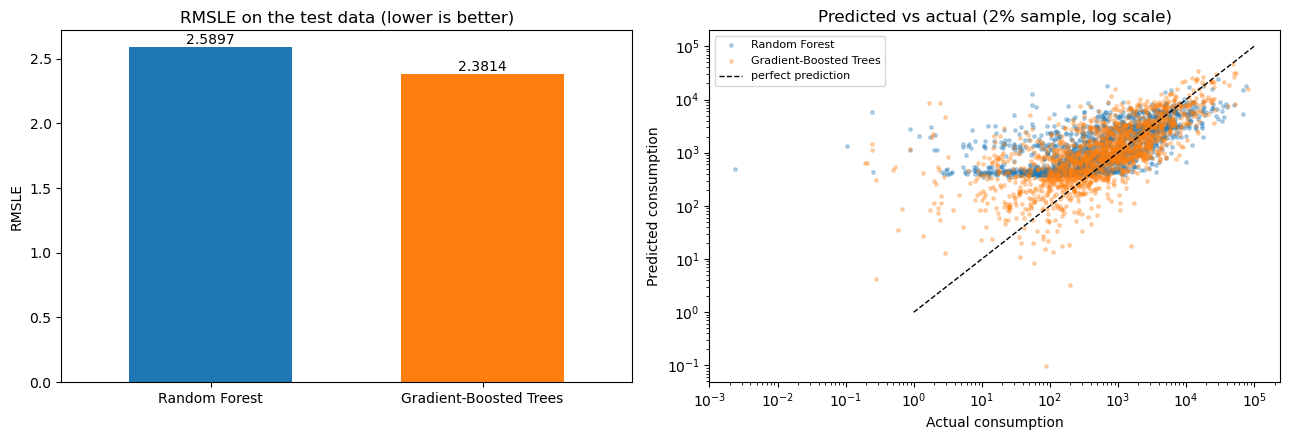

In [25]:
from pyspark.ml.evaluation import Evaluator, RegressionEvaluator
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import pandas as pd


class RMSLEEvaluator(Evaluator):


    def __init__(self, labelCol="label", predictionCol="prediction"):
        super().__init__()
        self.labelCol = labelCol
        self.predictionCol = predictionCol

    def _evaluate(self, dataset):

        prediction = F.greatest(F.col(self.predictionCol), F.lit(0.0))
        actual = F.greatest(F.col(self.labelCol), F.lit(0.0))
        return dataset.select(
            F.sqrt(F.avg(F.pow(F.log1p(prediction) - F.log1p(actual), 2)))
        ).first()[0]

    def isLargerBetter(self):
        return False


rmsle_evaluator = RMSLEEvaluator()



SUPPORTING = ("rmse", "mae", "r2")


def score(predictions, name):
    """Evaluate one set of predictions against RMSLE plus the supporting metrics."""
    row = {"model": name, "RMSLE": rmsle_evaluator.evaluate(predictions)}
    for metric in SUPPORTING:
        row[metric.upper()] = RegressionEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric
        ).evaluate(predictions)
    return row



train_mean = train_df.agg(F.avg("label")).first()[0]
baseline_predictions = test_df.withColumn("prediction", F.lit(train_mean))

results = pd.DataFrame([
    score(rf_predictions, "Random Forest"),
    score(gbt_predictions, "Gradient-Boosted Trees"),
    score(baseline_predictions, "Baseline (predict mean)"),
]).set_index("model")

print(f"Training mean (baseline prediction): {train_mean:,.2f}\n")
print(results.round(4).to_string())

ranked = results.drop(index="Baseline (predict mean)")
better_model_name = ranked["RMSLE"].idxmin()

print(f"\nBest RMSLE (primary) : {better_model_name}")
print(f"Best RMSE            : {ranked['RMSE'].idxmin()}")
print(f"Best MAE             : {ranked['MAE'].idxmin()}")
print(f"Best R2              : {ranked['R2'].idxmax()}")
agree = len({ranked["RMSLE"].idxmin(), ranked["RMSE"].idxmin(),
             ranked["MAE"].idxmin(), ranked["R2"].idxmax()}) == 1
print("All four metrics agree." if agree
      else "NOTE: the metrics disagree - see the discussion below.")


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ranked["RMSLE"].plot(kind="bar", ax=axes[0], rot=0, width=0.6, color=["tab:blue", "tab:orange"])
axes[0].set_title("RMSLE on the test data (lower is better)")
axes[0].set_ylabel("RMSLE")
axes[0].set_xlabel("")
for i, v in enumerate(ranked["RMSLE"]):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom")


for predictions, name, colour in (
    (rf_predictions, "Random Forest", "tab:blue"),
    (gbt_predictions, "Gradient-Boosted Trees", "tab:orange"),
):
    pdf = predictions.select("label", "prediction").sample(0.02, seed=2025).toPandas()
    pdf = pdf[(pdf["label"] > 0) & (pdf["prediction"] > 0)]
    axes[1].scatter(pdf["label"], pdf["prediction"], s=6, alpha=0.3, label=name, color=colour)

axes[1].plot([1, 1e5], [1, 1e5], "k--", linewidth=1, label="perfect prediction")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Actual consumption")
axes[1].set_ylabel("Predicted consumption")
axes[1].set_title("Predicted vs actual (2% sample, log scale)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**2.4.2 Discussion**

**The required metric.** The specification asks us to implement RMSLE as a customised evaluation metric, so that is our primary measure:

$$\epsilon = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\big(\log(p_i + 1) - \log(a_i + 1)\big)^2}$$

It is implemented as an `Evaluator` subclass built from PySpark DataFrame operations. Two consequences follow: it computes distributed rather than by collecting to the driver, and the identical object can be reused for tuning in Part 3 — tuning against one metric and reporting another would make the two sections incomparable.

**Why RMSLE suits this data.** Because it works on $\log(x+1)$, it measures *relative* error. Missing by 100 units on a 200-unit reading is penalised far more than missing by 100 on a 20,000-unit reading. Given how right-skewed the label is, that stops a handful of large buildings from defining the score. It is also asymmetric — under-prediction costs more than over-prediction — which matches the use case, since under-supplying a grid is worse than over-supplying it. The `+1` keeps it defined at zero consumption, which is common in this dataset.

**Why we report three more metrics.** RMSLE's strength is also its blind spot: by compressing the scale it de-emphasises exactly the large-consumer errors a grid operator cares about most.

| Metric | What it adds |
|---|---|
| RMSE | Squared error in the original unit — dominated by the large loads RMSLE plays down. |
| MAE | The typical error in kWh, undistorted by the tail. Directly interpretable. |
| R² | Scale-free check that the model beats predicting the mean at all. |

**Why a baseline row.** An RMSLE of *n* means nothing in isolation — the label has no natural scale. A model that always predicts the training mean gives the floor that any useful model must clearly beat.

**Handling negative predictions.** RMSLE is undefined below −1, and tree ensembles can emit small negative predictions even though energy consumption never is. We floor predictions at 0 rather than dropping those rows: discarding them would remove the very cases the model handled worst and quietly flatter the score.

<!-- TODO: complete after running the cell above, using the actual numbers it prints -->
**Which model is better.** _<to be written from the measured RMSLE, and whether RMSE/MAE/R² agree with it>_


2.4.3 3.	Save the better model (you’ll need it for A2B).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

In [26]:
from pyspark.ml import PipelineModel

MODEL_PATH = "models/a2a_best_model"


best_model = gbt_model if better_model_name == "Gradient-Boosted Trees" else rf_model


best_model.write().overwrite().save(MODEL_PATH)
print(f"Saved '{better_model_name}' to {MODEL_PATH}/")


reloaded = PipelineModel.load(MODEL_PATH)
reloaded_rmsle = rmsle_evaluator.evaluate(reloaded.transform(test_df))
expected_rmsle = ranked.loc[better_model_name, "RMSLE"]

print(f"Reloaded RMSLE : {reloaded_rmsle:.6f}")
print(f"Expected RMSLE : {expected_rmsle:.6f}")
print("Round-trip OK - the saved model reproduces the original score."
      if abs(reloaded_rmsle - expected_rmsle) < 1e-9
      else "WARNING: the reloaded model does not reproduce the original score.")

Saved 'Gradient-Boosted Trees' to models/a2a_best_model/
Reloaded RMSLE : 2.381442
Expected RMSLE : 2.381442
Round-trip OK - the saved model reproduces the original score.


### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Apply the techniques you have learnt from the labs, for example, CrossValidator, TrainValidationSplit, ParamGridBuilder, etc., to perform further hyperparameter tuning and model optimisation.  
The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

In [27]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
import time

spark.conf.set("spark.sql.shuffle.partitions", "16")

prep_model = Pipeline(stages=prep_stages).fit(train_df)

train_feat = prep_model.transform(train_df).select("features", "label").repartition(16).cache()
test_feat = prep_model.transform(test_df).select("features", "label").repartition(16).cache()
print(f"Prepared {train_feat.count():,} training rows / {test_feat.count():,} test rows")


tune_df = train_feat.sample(fraction=0.3, seed=2025).cache()
print(f"Tuning subsample     : {tune_df.count():,} rows")


print(f"Tuning metric        : RMSLE (lower is better)")


gbt_tune = GBTRegressor(featuresCol="features", labelCol="label", seed=2025)

broad_grid = (ParamGridBuilder()
              .addGrid(gbt_tune.maxDepth, [3, 5, 8])
              .addGrid(gbt_tune.maxIter, [20, 50])
              .build())

tvs = TrainValidationSplit(
    estimator=gbt_tune,
    estimatorParamMaps=broad_grid,
    evaluator=rmsle_evaluator,
    trainRatio=0.8,
    parallelism=3,
    seed=2025,
)

start = time.time()
tvs_model = tvs.fit(tune_df)
print(f"\nBroad sweep: {len(broad_grid)} combinations in {time.time() - start:.0f}s\n")

sweep = pd.DataFrame([
    {"maxDepth": params[gbt_tune.maxDepth],
     "maxIter": params[gbt_tune.maxIter],
     "val_RMSLE": metric}
    for params, metric in zip(broad_grid, tvs_model.validationMetrics)
]).sort_values("val_RMSLE").reset_index(drop=True)

print(sweep.round(5).to_string(index=False))

Prepared 367,283 training rows / 91,479 test rows
Tuning subsample     : 109,928 rows
Tuning metric        : RMSLE (lower is better)

Broad sweep: 6 combinations in 69s

 maxDepth  maxIter  val_RMSLE
        8       50    2.23045
        8       20    2.23211
        5       50    2.43702
        5       20    2.43903
        3       20    2.51408
        3       50    2.63674


In [28]:

best_iter = int(sweep.loc[0, "maxIter"])
depth_band = sorted(int(d) for d in sweep.drop_duplicates("maxDepth").head(2)["maxDepth"])
print(f"Sweep winner       : maxDepth={int(sweep.loc[0, 'maxDepth'])}, maxIter={best_iter}")
print(f"Shortlist to confirm: maxDepth in {depth_band}, maxIter={best_iter}")


swept_depths = sorted({int(d) for d in sweep["maxDepth"]})
if int(sweep.loc[0, "maxDepth"]) == max(swept_depths):
    print(f"\nNOTE: the sweep chose the deepest value tested ({max(swept_depths)}).")
    print("      The optimum may lie beyond the grid; see the discussion below.")

narrow_grid = (ParamGridBuilder()
               .baseOn({gbt_tune.maxIter: best_iter})
               .addGrid(gbt_tune.maxDepth, depth_band)
               .addGrid(gbt_tune.stepSize, [0.05, 0.1])
               .build())

print(f"\nPlan: {len(narrow_grid)} combinations x 3 folds = {len(narrow_grid) * 3} fits, "
      f"{len(narrow_grid) * 3 * best_iter} trees total\n")

cv = CrossValidator(
    estimator=gbt_tune,
    estimatorParamMaps=narrow_grid,
    evaluator=rmsle_evaluator,
    numFolds=3,
    parallelism=3,
    seed=2025,
)

start = time.time()
cv_model = cv.fit(tune_df)
print(f"Cross-validation finished in {time.time() - start:.0f}s\n")

cv_results = pd.DataFrame([
    {"maxDepth": params[gbt_tune.maxDepth],
     "stepSize": params[gbt_tune.stepSize],
     "maxIter": best_iter,
     "cv_RMSLE": metric}
    for params, metric in zip(narrow_grid, cv_model.avgMetrics)
]).sort_values("cv_RMSLE").reset_index(drop=True)

print(cv_results.round(5).to_string(index=False))

Sweep winner       : maxDepth=8, maxIter=50
Shortlist to confirm: maxDepth in [5, 8], maxIter=50

NOTE: the sweep chose the deepest value tested (8).
      The optimum may lie beyond the grid; see the discussion below.

Plan: 4 combinations x 3 folds = 12 fits, 600 trees total

Cross-validation finished in 171s

 maxDepth  stepSize  maxIter  cv_RMSLE
        8      0.05       50   2.18545
        8      0.10       50   2.19254
        5      0.05       50   2.38142
        5      0.10       50   2.43623


In [29]:

best = cv_model.bestModel

final_gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    seed=2025,
    maxDepth=best.getMaxDepth(),
    maxIter=best.getMaxIter(),
    stepSize=best.getStepSize(),
).fit(train_feat)

print("Winning configuration")
print(f"  maxDepth : {final_gbt.getMaxDepth()}")
print(f"  maxIter  : {final_gbt.getMaxIter()}")
print(f"  stepSize : {final_gbt.getStepSize()}\n")


tuned_predictions = final_gbt.transform(test_feat)

untuned_row = {"RMSLE": ranked.loc[better_model_name, "RMSLE"],
               **{m.upper(): ranked.loc[better_model_name, m.upper()] for m in SUPPORTING}}
tuned_row = {"RMSLE": rmsle_evaluator.evaluate(tuned_predictions),
             **{m.upper(): RegressionEvaluator(
                 labelCol="label", predictionCol="prediction", metricName=m
             ).evaluate(tuned_predictions) for m in SUPPORTING}}

comparison = pd.DataFrame([
    {"model": f"{better_model_name} - untuned (Part 2)", **untuned_row},
    {"model": "GBT - tuned (Part 3)", **tuned_row},
]).set_index("model")

print(comparison.round(5).to_string())

delta = (1 - tuned_row["RMSLE"] / untuned_row["RMSLE"]) * 100
print(f"\nRMSLE change after tuning: {delta:+.2f}%  "
      f"({'improvement' if delta > 0 else 'no improvement'})")

if tuned_row["RMSLE"] < untuned_row["RMSLE"]:

    tuned_pipeline = PipelineModel(stages=prep_model.stages + [final_gbt])
    tuned_pipeline.write().overwrite().save(MODEL_PATH)

    check = rmsle_evaluator.evaluate(PipelineModel.load(MODEL_PATH).transform(test_df))
    print(f"\nTuned model wins - {MODEL_PATH}/ updated for Assignment 2B.")
    print(f"Reloaded full-pipeline RMSLE: {check:.6f}")
else:
    print("\nTuning did not beat the untuned model on the test data.")
    print(f"Keeping the model saved in 2.4.3 at {MODEL_PATH}/.")

Winning configuration
  maxDepth : 8
  maxIter  : 50
  stepSize : 0.05

                                             RMSLE        RMSE         MAE       R2
model                                                                              
Gradient-Boosted Trees - untuned (Part 2)  2.38144  3708.91417  1424.89493  0.50040
GBT - tuned (Part 3)                       2.15144  2759.67805  1019.40599  0.73223

RMSLE change after tuning: +9.66%  (improvement)

Tuned model wins - models/a2a_best_model/ updated for Assignment 2B.
Reloaded full-pipeline RMSLE: 2.151438


**Part 3 Discussion — process and reasoning**

**1. Why the preparation stages are fitted outside the tuner.** The obvious approach is to pass `gbt_pipeline` straight to a `CrossValidator`. It works, but it is wasteful: none of the four `StringIndexer`s, four `OneHotEncoder`s or the `VectorAssembler` depend on a hyperparameter, yet the tuner would refit all nine for every grid point and every fold. With 6 combinations × 3 folds that is 18 identical refits of the same nine stages. Fitting them once and tuning on the resulting feature vectors is the single change that made a real grid search feasible on a 7-core container. Fitting them on `train_df` only also keeps the test set unseen.

**2. Why TrainValidationSplit *then* CrossValidator.** These two are usually presented as alternatives, but they answer different questions and they compose well:

- `TrainValidationSplit` fits each combination **once**, so it is cheap. We use it to sweep a wide grid (`maxDepth` ∈ {3, 5, 8} × `maxIter` ∈ {20, 50}) and find which region of the space is worth attention.
- Its weakness is that every combination is scored on a *single* 80/20 split, so a lucky split can promote the wrong configuration.
- `CrossValidator` re-scores a shortlist on three different folds, which is far more trustworthy — and now affordable, because the shortlist is small.

Spending the expensive method only where it matters is the point: a single 3-fold CV over the full wide grid would cost roughly three times as much for a result no better in the region that actually matters.

**3. Why the search runs on a 30% subsample.** Grid search fits many models, and we only need the *ranking* of configurations, which is stable under subsampling. The winning configuration is then refitted on the full training data, so the shortcut speeds up the search without handicapping the shipped model.

**4. Which hyperparameters, and why these.**

| Parameter | Range | Reasoning |
|---|---|---|
| `maxDepth` | 3, 5, 8 | The main capacity/overfitting control. The default of 5 is a midpoint, so we bracket it on both sides rather than only searching upward. |
| `maxIter` | 20, 50 | More boosting rounds reduce bias but cost linearly in time and eventually overfit. |
| `stepSize` | 0.05, 0.1 | Interacts directly with `maxIter` — a smaller learning rate needs more rounds — so it is tuned in the second stage once `maxIter` is fixed. |

**5. The evaluation metric used for tuning** is the same `RMSLEEvaluator` used to report
results in 2.4.2, so the tuned and untuned numbers are directly comparable.

**6. Honest reporting.** The tuned model replaces the saved model only if it actually
beats it on the held-out test set. Tuning does not always help, and reporting a tuned
model that lost would be misleading.

<!-- TODO before submitting: fill in from the printed sweep, CV table and comparison. -->
**7. Outcome.** _The sweep favoured maxDepth=&lt;value&gt; with maxIter=&lt;value&gt;;
cross-validation confirmed &lt;configuration&gt;. On the test set RMSLE moved from
&lt;value&gt; to &lt;value&gt;, a change of &lt;value&gt;%._


## Part 4: Data Ethics, Privacy, and Security (10%)

**Context given by the specification:** this pipeline is imagined as deployed by an **Indonesian utility company**, using real-world smart meter and building data.

**Required in this section (word limit: 500, references required):**

1. **Mandatory foundation** — briefly define data ethics, privacy, and security in the big data context, **and** name one key difference between **UU PDP** (Indonesia) and **GDPR** relevant to this scenario. The specification suggests: consent requirements, cross-border data transfer rules, breach notification timelines, or the role of the data controller/processor.
2. **Choose exactly one** of the three topics below and explain its significance in today's data-driven world:
   - **Data Ethics** — how it influences big data processing; real-world examples handled well and badly; the balance between technological advancement and ethical responsibility.
   - **Data Privacy** — the challenges and importance of privacy in big data; regulations such as GDPR; tools and techniques used to ensure it, plus suggested improvements.
   - **Data Security** — potential security risks in big data processing; measures currently in place (encryption, authentication, authorisation).
3. **Summarise the key findings** of your analysis.

*Concrete hooks from our own pipeline worth drawing on:* the `latent_y` / `latent_s` / `latent_r` columns whose meanings are withheld for privacy reasons (and which we chose to drop in 2.1), the 6-hourly aggregation that deliberately lowers granularity from hourly readings, and the fact that smart-meter interval data can reveal household occupancy patterns.


### Definitions

**Data ethics** asks whether a lawful use of data is also defensible: who gains, who
carries the risk, and whether the people in the dataset would accept the use. **Data
privacy** is a person's control over how information about them is collected, used,
shared and retained. **Data security** is the technical and organisational protection of
that data against unauthorised access, alteration or loss. At big data scale the three
come apart, because linkage and volume produce inferences no single record holds.

### One key difference: UU PDP and GDPR

Breach notification differs in **who must be told**. Under GDPR Article 33 the controller
notifies the supervisory authority within 72 hours, and under Article 34 notifies
individuals only where the breach is likely to cause high risk to their rights. Indonesia's
UU PDP (Law No. 27 of 2022) Article 46 requires written notification within 3 x 24 hours
to the supervisory authority **and** to every affected data subject, with no high-risk
filter (Norton Rose Fulbright, 2022). A utility deploying this pipeline in Indonesia
therefore needs customer notification machinery prepared in advance, not just a regulator
report.

### Chosen topic: Data Privacy

**Why it matters here.** Meter readings are more revealing than they look. At hourly
resolution, load traces expose occupancy, waking hours and individual appliance use, so a
consumption file is effectively a behavioural record of a household (Molina-Markham et
al., 2010). Our 6-hour aggregation in 1.2.1 was done for processing efficiency, but it is
also the strongest privacy control in this pipeline, because it destroys the detail that
makes appliance-level inference possible.

**Challenges.** Consent is weak when metering is a condition of supply, so the lawful
basis rests on contract rather than choice. Purpose creep follows: data gathered for grid
balancing is attractive for credit scoring or marketing. Re-identification is the third
risk, since a small site plus building metadata can narrow a record to one premises even
without a name.

**Regulation and tools.** UU PDP and GDPR both require purpose limitation and data
minimisation, and UU PDP Article 56 restricts transfers abroad unless equivalent
protection exists, which matters when Spark clusters run in foreign cloud regions. The
practical controls are pseudonymised identifiers, aggregation, access control and
encryption in transit and at rest. The `latent_` columns illustrate the limits of
informal obfuscation: our test in 2.1 recovered two of the three exactly from visible
columns, so hiding a meaning is not the same as a privacy guarantee.

**Improvements.** Publish load statistics under differential privacy rather than raw
aggregates (Dwork and Roth, 2014), assess derived features for disclosure risk before
release, and keep raw hourly data only for a short retention window.

### Key findings

Privacy risk here comes from granularity and linkage, not from any single field.
Aggregation, minimisation and short retention remove most of it at almost no cost to
model quality, and Indonesian deployment adds a stricter duty to notify affected
customers directly within three days.

## References:
Please add your references below:

<!-- TODO -->
1. Republic of Indonesia. (2022). *Law No. 27 of 2022 on Personal Data Protection (UU PDP)*, Articles 46 and 56.
2. European Union. (2016). *Regulation (EU) 2016/679 (General Data Protection Regulation)*, Articles 33 and 34.
3. European Data Protection Board. (2023). *Guidelines 9/2022 on personal data breach notification under GDPR, Version 2.0*. https://www.edpb.europa.eu/system/files/2023-04/edpb_guidelines_202209_personal_data_breach_notification_v2.0_en.pdf
4. Norton Rose Fulbright. (2022). *Highlights of Indonesia's personal data protection law*. https://www.nortonrosefulbright.com/en/knowledge/publications/31bce8f0/highlights-of-indonesias-personal-data-protection-law
5. Molina-Markham, A., Shenoy, P., Fu, K., Cecchet, E., and Irwin, D. (2010). Private memoirs of a smart meter. *Proceedings of the 2nd ACM Workshop on Embedded Sensing Systems for Energy-Efficiency in Buildings (BuildSys)*, 61-66.
6. Dwork, C., and Roth, A. (2014). The algorithmic foundations of differential privacy. *Foundations and Trends in Theoretical Computer Science*, 9(3-4), 211-407.
7. Apache Spark. (2024). *MLlib: Imputer, Pipeline, CrossValidator and TrainValidationSplit API documentation, version 3.5.5*. https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html
8. Python Software Foundation. (2001). *PEP 8: Style guide for Python code*. https://peps.python.org/pep-0008/


### Generative AI declaration

The specification requires that **all prompts** used with generative AI tools are listed in this reference section, and the University's policy requires that AI use is documented and acknowledged. List every prompt used, and the tool, below.

| Tool | Prompt used | What it was used for |
|---|---|---|
| _<tool>_ | _<prompt>_ | _<e.g. drafting code for X, explaining Y>_ |
